In [1]:
# Parte 1: Preparación del entorno
#!pip install pandas numpy matplotlib seaborn scikit-learn

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE


**Opcion de modelos no supervisados sin genero al ser una variable de 1 y 0 afecta el algoritmo le está dando mucha importancia al género para dividir a los usuarios de uso medio**

     Device Model Operating System  App Usage Time (min/day)  \
0  Google Pixel 5          Android                       393   
1       OnePlus 9          Android                       268   
2    Xiaomi Mi 11          Android                       154   
3  Google Pixel 5          Android                       239   
4       iPhone 12              iOS                       187   

   Screen On Time (hours/day)  Battery Drain (mAh/day)  \
0                         6.4                     1872   
1                         4.7                     1331   
2                         4.0                      761   
3                         4.8                     1676   
4                         4.3                     1367   

   Number of Apps Installed  Data Usage (MB/day)  Age  Gender  \
0                        67                 1122   40    Male   
1                        42                  944   47  Female   
2                        32                  322   42    Male   
3     

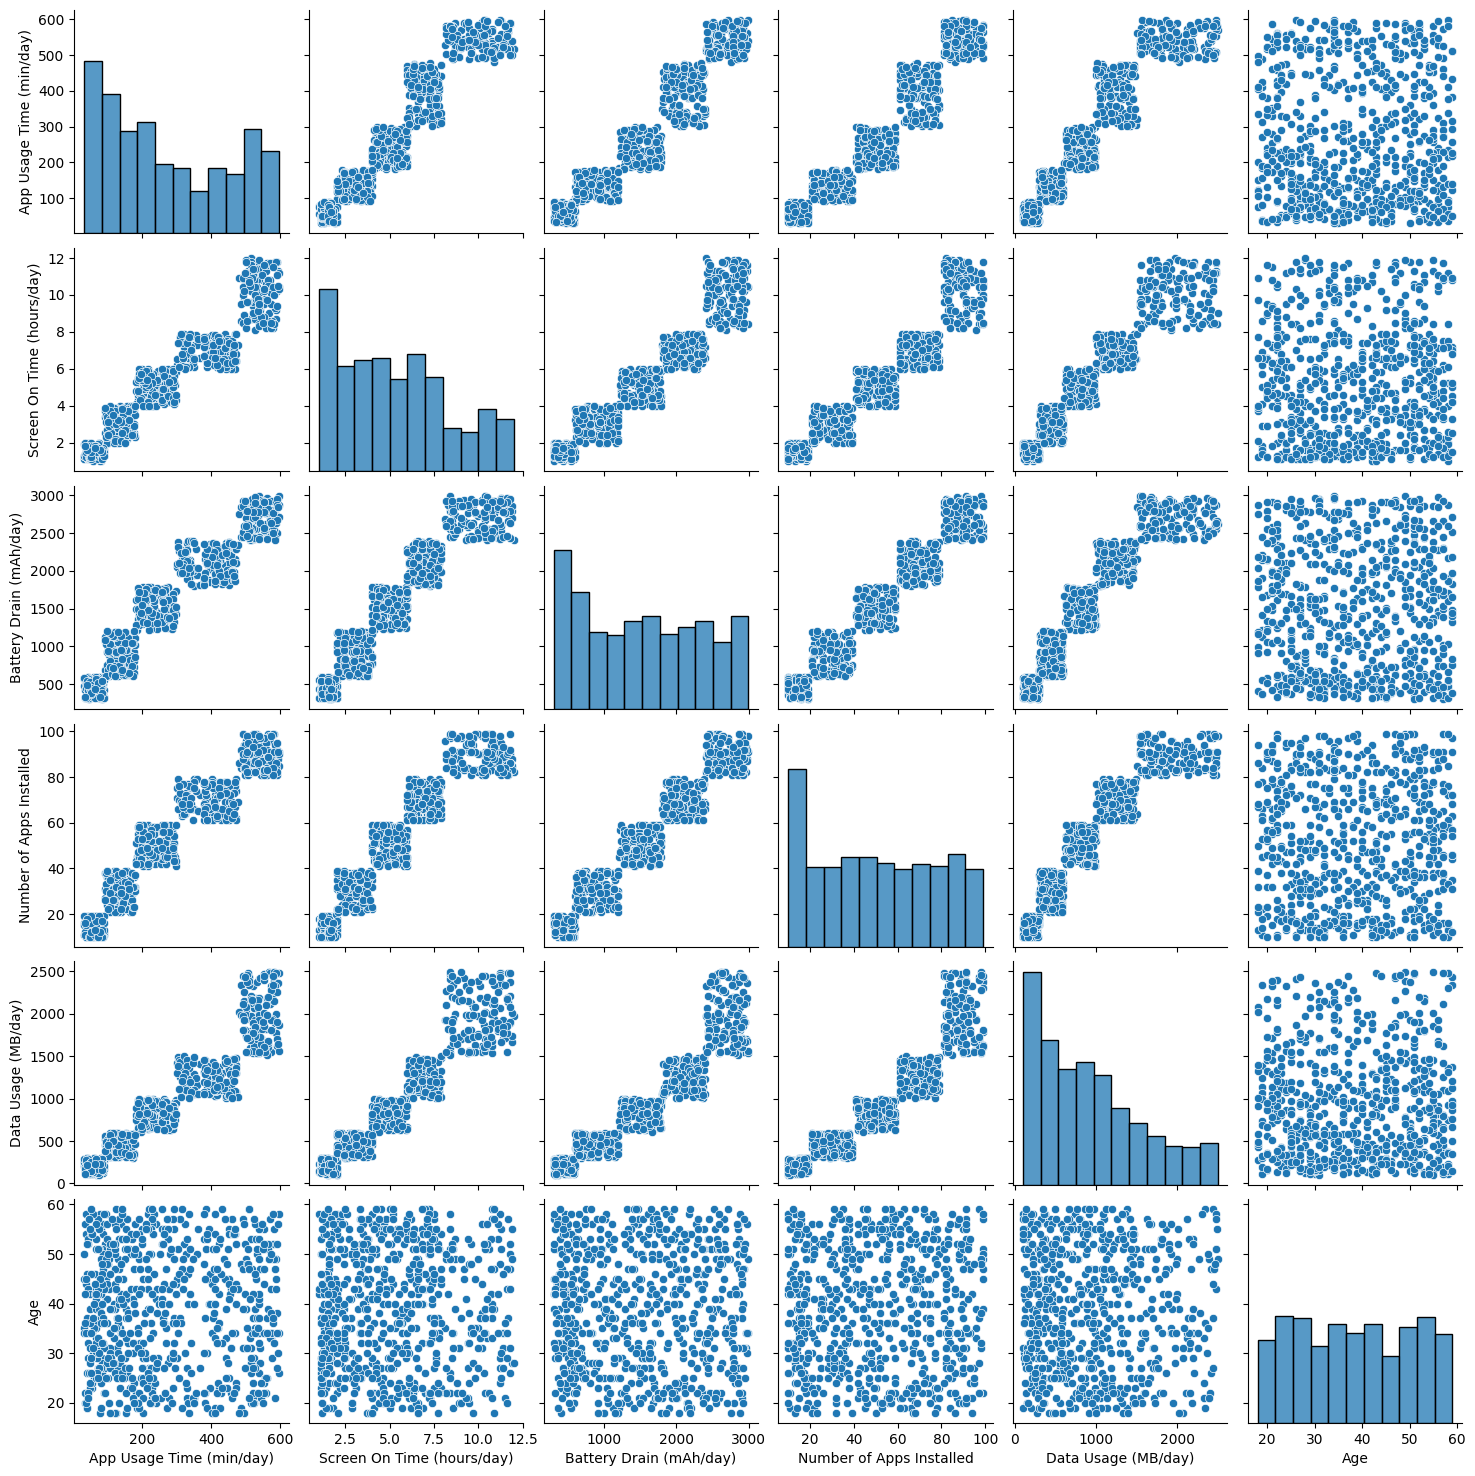

In [45]:
# Parte 2: Carga y análisis exploratorio de los datos
df = pd.read_csv('user_behavior_dataset.csv')
#eliminar user Id para evitar que influya en el análisis
df.drop('User ID', axis=1, inplace=True)

print(df.head())
print(df.info())
print(df.describe())

# Visualización de la distribución
sns.pairplot(df[['App Usage Time (min/day)', 'Screen On Time (hours/day)', 'Battery Drain (mAh/day)','Number of Apps Installed','Data Usage (MB/day)','Age']])
plt.show()


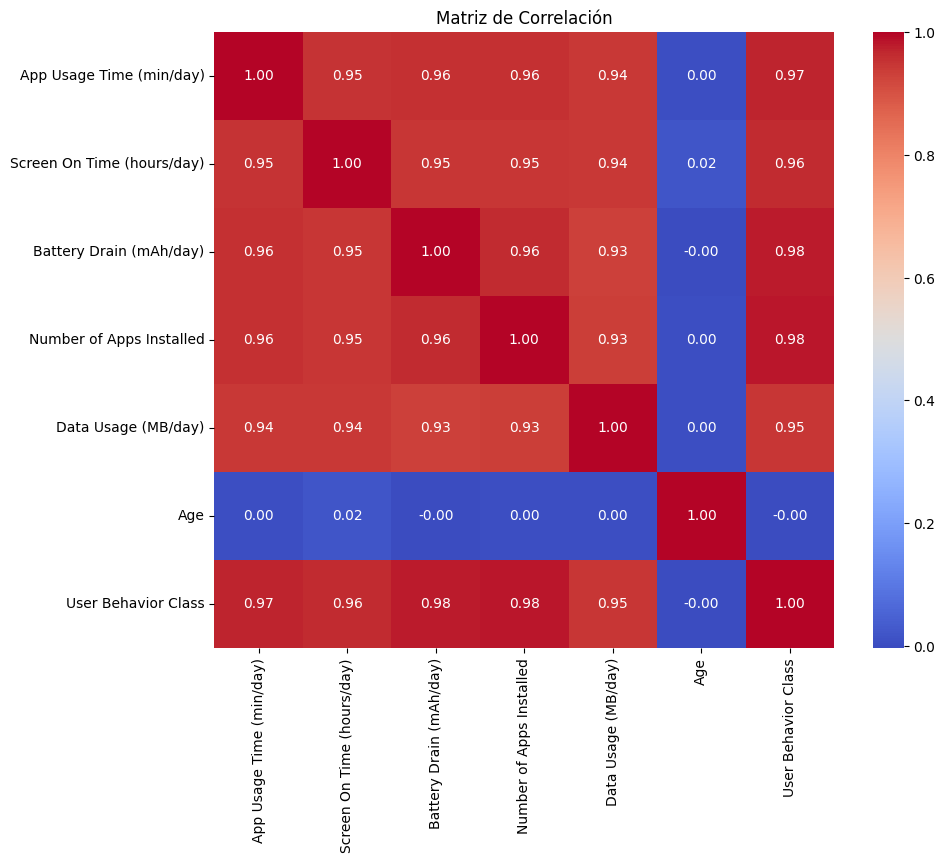

In [46]:
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Matriz de Correlación')
plt.show()

**¿Por qué es necesario escalar para K-Means y DBSCAN?**

Ambos algoritmos usan distancias (por ejemplo, distancia euclidiana) para agrupar los datos. Si una variable tiene un rango mucho mayor que otra, dominará la distancia total y, por lo tanto, tendrá más peso en la decisión del algoritmo, aunque no necesariamente sea más importante.

Ejemplo:
* Age: varía entre 18 y 70.

* Annual Income (k$): varía entre 15 y 137.

* Spending Score (1-100): varía entre 1 y 99.


Si no escalas, Annual Income influirá más en el cálculo de distancias simplemente porque sus valores son más grandes.

In [47]:
# Parte 3: Preprocesamiento
X = df[['App Usage Time (min/day)', 'Screen On Time (hours/day)', 'Battery Drain (mAh/day)','Number of Apps Installed','Data Usage (MB/day)','Age']]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


**¿Qué es K-Means Clustering?**

Es un algoritmo no supervisado que divide los datos en K grupos (clusters) con base en la distancia entre puntos. Cada grupo se forma alrededor de un centroide. El objetivo es minimizar la distancia total entre los puntos y su centroide.

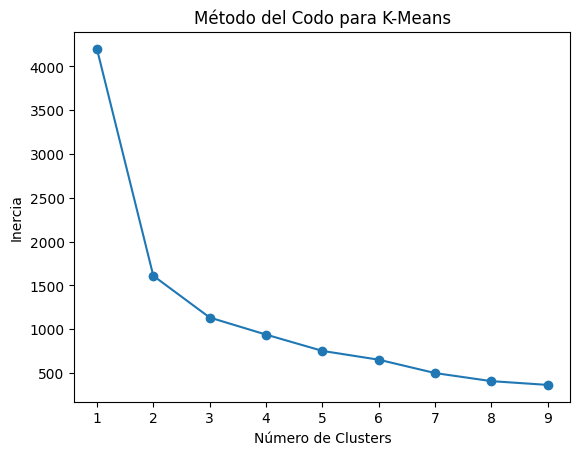

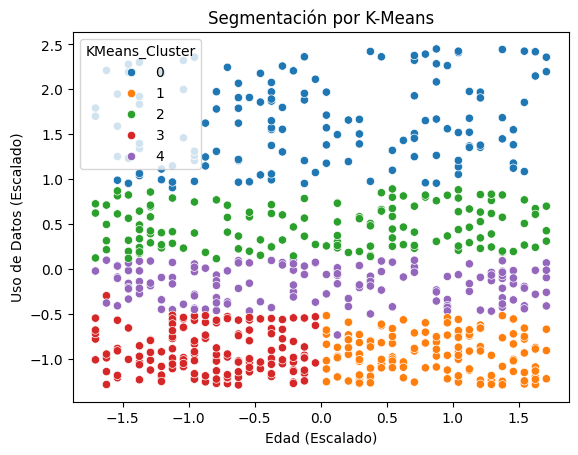

In [48]:
# Parte 4.1: Clustering con K-Means
inertia = []
for k in range(1, 10):
    km = KMeans(n_clusters=k,n_init='auto', random_state=42)
    km.fit(X_scaled)
    inertia.append(km.inertia_)

# Método del Codo
plt.plot(range(1, 10), inertia, marker='o')
plt.xlabel('Número de Clusters') # Numero de grupos
plt.ylabel('Inercia') # la suma de las distancias cuadradas de cada punto a su centroide (cuánto error hay dentro de cada cluster).
plt.title('Método del Codo para K-Means')
plt.show()

# Ajuste del modelo con K óptimo (ej. 5)
kmeans = KMeans(n_clusters=5, random_state=42)
df['KMeans_Cluster'] = kmeans.fit_predict(X_scaled)

sns.scatterplot(x=X_scaled[:, 5], y=X_scaled[:, 4], hue=df['KMeans_Cluster'], palette='tab10')
plt.xlabel('Edad (Escalado)')
plt.ylabel('Uso de Datos (Escalado)')
plt.title('Segmentación por K-Means')
plt.show()


In [34]:
# Parte 4.1.1: Interpretación de Clustering con K-Means
df.groupby('KMeans_Cluster')[['App Usage Time (min/day)', 'Screen On Time (hours/day)', 'Battery Drain (mAh/day)','Number of Apps Installed','Data Usage (MB/day)','Age']].mean()


,App Usage Time (min/day),Screen On Time (hours/day),Battery Drain (mAh/day),Number of Apps Installed,Data Usage (MB/day),Age
KMeans_Cluster,,,,,,
0,541.419118,10.114706,2701.014706,89.250000,1974.772059,38.176471
1,97.854015,2.399270,663.036496,23.437956,319.437956,48.569343
2,395.748201,6.909353,2105.805755,69.920863,1232.230216,38.676259
3,97.151724,2.193103,690.303448,22.579310,344.413793,28.717241
4,235.349650,4.952448,1514.937063,49.895105,820.055944,38.825175


¿Qué es DBSCAN?

DBSCAN es un algoritmo de clustering basado en densidad. A diferencia de K-Means (que requiere que definas el número de clusters k), DBSCAN:

* Encuentra agrupaciones densas de puntos sin necesidad de saber cuántos clusters hay.

* Identifica automáticamente "ruido" o "outliers", etiquetándolos como -1.

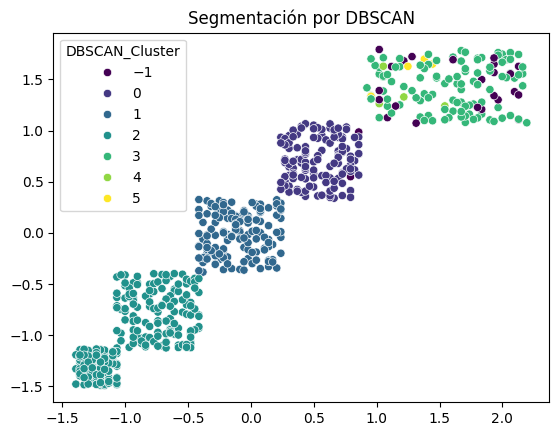

In [49]:
# Parte 4.2: Clustering con DBSCAN
dbscan = DBSCAN(eps=0.6, min_samples=5) # eps = radio máximo para considerar que dos puntos están “cerca”./ min_samples =  número mínimo de puntos vecinos necesarios para formar un cluster.
df['DBSCAN_Cluster'] = dbscan.fit_predict(X_scaled)

sns.scatterplot(x=X_scaled[:, 1], y=X_scaled[:, 2], hue=df['DBSCAN_Cluster'], palette='viridis')
plt.title('Segmentación por DBSCAN')
plt.show()


In [50]:
# Parte 4.2.1: Interpretando los Clustering con DBSCAN
df['DBSCAN_Cluster'].value_counts()
df.groupby('DBSCAN_Cluster')[['App Usage Time (min/day)', 'Screen On Time (hours/day)', 'Battery Drain (mAh/day)','Number of Apps Installed','Data Usage (MB/day)','Age']].mean()





,App Usage Time (min/day),Screen On Time (hours/day),Battery Drain (mAh/day),Number of Apps Installed,Data Usage (MB/day),Age
DBSCAN_Cluster,,,,,,
-1,525.500000,10.107692,2663.461538,89.269231,2224.538462,40.269231
0,396.058394,6.896350,2105.116788,69.839416,1228.992701,38.802920
1,235.398601,4.955944,1515.055944,50.000000,822.013986,38.678322
2,97.468085,2.291489,676.996454,22.943262,331.287234,38.436170
3,542.076923,10.153846,2697.634615,88.730769,1880.269231,37.759615
4,550.000000,8.975000,2643.000000,96.250000,2452.250000,49.000000
5,535.750000,9.125000,2817.000000,88.750000,2070.500000,20.500000


In [51]:


# Parte 4.2.1: Interpretando los Clustering con DBSCAN sin atípicos
df_no_noise = df[df['DBSCAN_Cluster'] != -1]
df_no_noise.groupby('DBSCAN_Cluster')[['App Usage Time (min/day)', 'Screen On Time (hours/day)', 'Battery Drain (mAh/day)','Number of Apps Installed','Data Usage (MB/day)','Age']].mean()

,App Usage Time (min/day),Screen On Time (hours/day),Battery Drain (mAh/day),Number of Apps Installed,Data Usage (MB/day),Age
DBSCAN_Cluster,,,,,,
0,396.058394,6.896350,2105.116788,69.839416,1228.992701,38.802920
1,235.398601,4.955944,1515.055944,50.000000,822.013986,38.678322
2,97.468085,2.291489,676.996454,22.943262,331.287234,38.436170
3,542.076923,10.153846,2697.634615,88.730769,1880.269231,37.759615
4,550.000000,8.975000,2643.000000,96.250000,2452.250000,49.000000
5,535.750000,9.125000,2817.000000,88.750000,2070.500000,20.500000


**¿Qué es PCA?**

PCA (Principal Component Analysis) es una técnica matemática que:

* Reduce el número de variables (dimensiones) de un dataset.

* Conserva la mayor parte de la variabilidad (información) de los datos originales.

* Transforma los datos a componentes principales que son combinaciones lineales de las variables originales.

¿Qué significa reducir de 3 a 2 dimensiones?

Reduces de:

Tres variables originales (Edad, Ingreso, Gasto)

a:

Dos nuevas variables artificiales, llamadas Componentes principales: PC1 y PC2.

Cada una de estas componentes es una combinación lineal de las variables originales. Por ejemplo:



* PC1=0.5⋅Edad+0.7⋅Ingreso+0.5⋅Gasto


* PC2=−0.6⋅Edad+0.4⋅Ingreso+0.7⋅Gasto

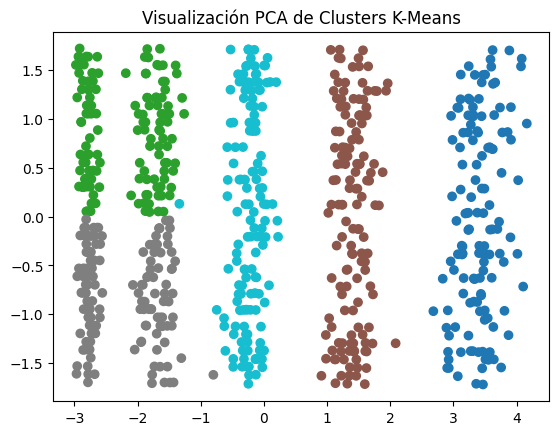

In [52]:
# Parte 5.1: Reducción de dimensionalidad con PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.scatter(X_pca[:, 0], X_pca[:, 1], c=df['KMeans_Cluster'], cmap='tab10')
plt.title('Visualización PCA de Clusters K-Means')
plt.show()


In [53]:
# Parte 5.1.1: Interpretación de Reducción de dimensionalidad con PCA
df.groupby('KMeans_Cluster')[['App Usage Time (min/day)', 'Screen On Time (hours/day)', 'Battery Drain (mAh/day)','Number of Apps Installed','Data Usage (MB/day)','Age']].mean()


,App Usage Time (min/day),Screen On Time (hours/day),Battery Drain (mAh/day),Number of Apps Installed,Data Usage (MB/day),Age
KMeans_Cluster,,,,,,
0,541.419118,10.114706,2701.014706,89.250000,1974.772059,38.176471
1,97.854015,2.399270,663.036496,23.437956,319.437956,48.569343
2,395.748201,6.909353,2105.805755,69.920863,1232.230216,38.676259
3,97.151724,2.193103,690.303448,22.579310,344.413793,28.717241
4,235.349650,4.952448,1514.937063,49.895105,820.055944,38.825175


In [54]:
# Parte 5.1.2: Interpretación detallada de Reducción de dimensionalidad con PCA
# Mostrar algunos usuarios por cluster
for i in range(4):
    print(f"\nCluster {i}")
    display(df[df['KMeans_Cluster'] == i][['App Usage Time (min/day)', 'Screen On Time (hours/day)', 'Battery Drain (mAh/day)','Number of Apps Installed','Data Usage (MB/day)','Age']].head())



Cluster 0


,App Usage Time (min/day),Screen On Time (hours/day),Battery Drain (mAh/day),Number of Apps Installed,Data Usage (MB/day),Age
7,543,11.4,2956,82,1702,31
15,503,10.4,2571,84,2025,39
19,577,8.5,2774,89,2192,29
21,576,11.6,2803,82,1553,43
27,512,10.5,2409,89,1599,33



Cluster 1


,App Usage Time (min/day),Screen On Time (hours/day),Battery Drain (mAh/day),Number of Apps Installed,Data Usage (MB/day),Age
2,154,4.0,761,32,322,42
16,132,3.6,628,32,344,47
20,93,2.6,681,37,302,45
25,91,3.4,1073,38,451,52
33,46,2.0,457,14,105,58



Cluster 2


,App Usage Time (min/day),Screen On Time (hours/day),Battery Drain (mAh/day),Number of Apps Installed,Data Usage (MB/day),Age
0,393,6.4,1872,67,1122,40
6,350,7.3,1802,66,1054,21
8,340,7.7,2138,75,1053,42
9,424,6.6,1957,75,1301,42
12,462,6.2,2303,65,1099,57



Cluster 3


,App Usage Time (min/day),Screen On Time (hours/day),Battery Drain (mAh/day),Number of Apps Installed,Data Usage (MB/day),Age
5,99,2.0,940,35,564,31
10,53,1.4,435,17,162,34
18,81,1.4,558,16,297,26
35,32,1.2,580,19,153,20
36,122,3.3,755,30,573,26


C:\Users\andre\AppData\Local\Temp\ipykernel_6948\4017753449.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='KMeans_Cluster', y='App Usage Time (min/day)', data=df, palette='tab10')


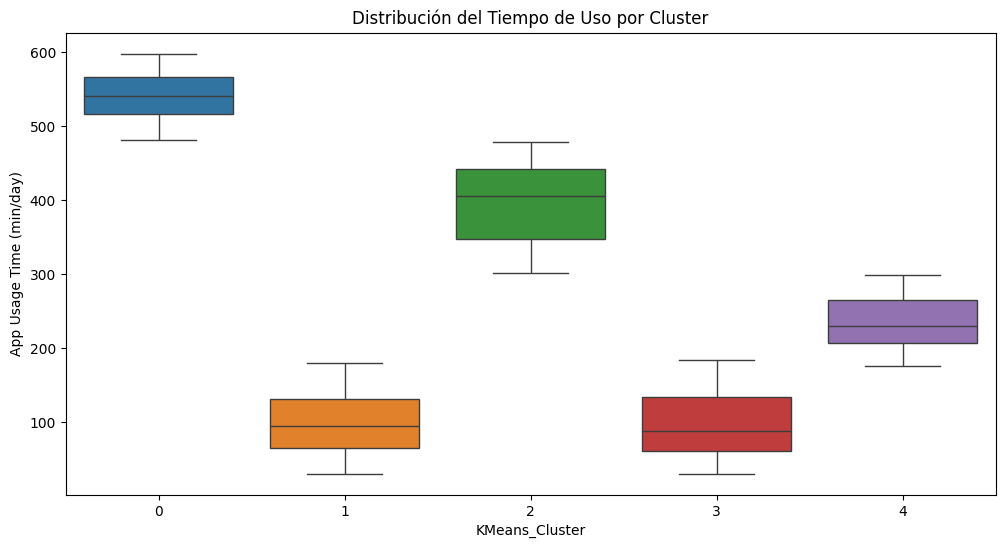

In [55]:
plt.figure(figsize=(12, 6))
sns.boxplot(x='KMeans_Cluster', y='App Usage Time (min/day)', data=df, palette='tab10')
plt.title('Distribución del Tiempo de Uso por Cluster')
plt.show()

**¿Qué es t-SNE?**

t-SNE es una técnica de reducción de dimensionalidad no lineal diseñada específicamente para visualización de datos complejos en 2D o 3D.

A diferencia de PCA (que usa combinaciones lineales de variables para preservar la varianza), t-SNE preserva la estructura local de los datos. Es decir:

Los puntos que estaban cerca en el espacio original seguirán cerca en el nuevo espacio 2D.


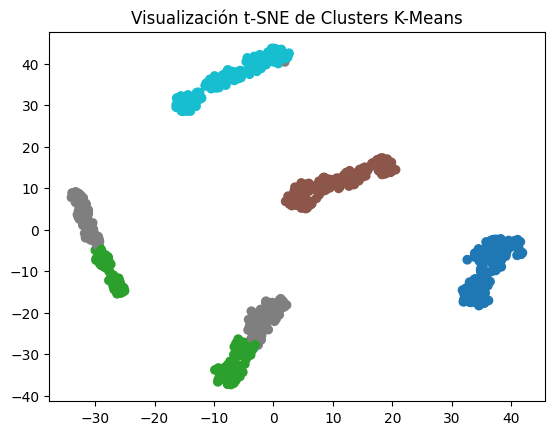

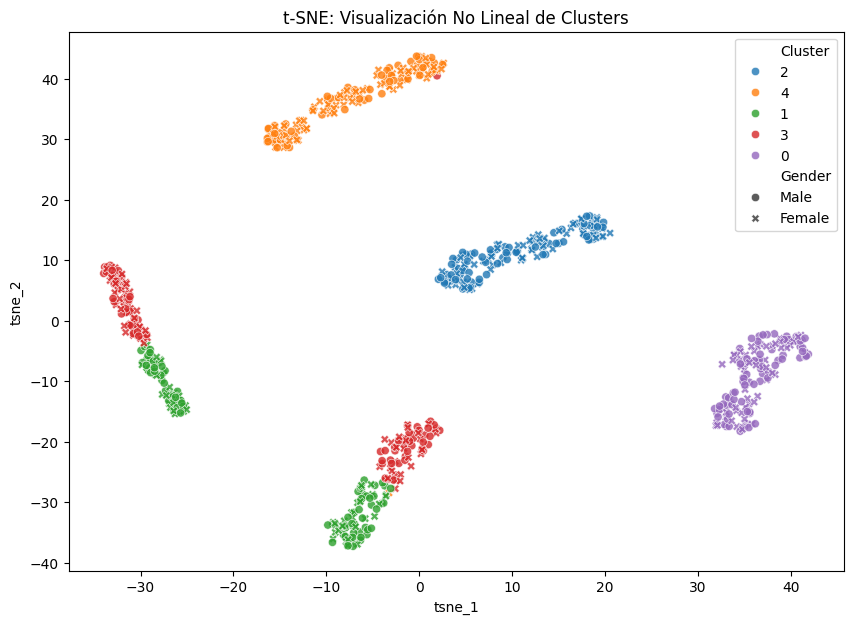

In [56]:
# Parte 5.2: Reducción de dimensionalidad con t-SNE
tsne = TSNE(n_components=2, perplexity=30, learning_rate=200, random_state=42) # cuántos vecinos cercanos considera t-SNE / cuánto se mueven los puntos
X_tsne = tsne.fit_transform(X_scaled)

plt.scatter(X_tsne[:, 0], X_tsne[:, 1], c=df['KMeans_Cluster'], cmap='tab10')
plt.title('Visualización t-SNE de Clusters K-Means')
plt.show()
# Creamos un DataFrame para t-SNE
df_tsne = pd.DataFrame(X_tsne, columns=['tsne_1', 'tsne_2'])
df_tsne['Cluster'] = df['KMeans_Cluster'].astype(str)
df_tsne['Gender'] = df['Gender']

plt.figure(figsize=(10, 7))
sns.scatterplot(
    data=df_tsne, x='tsne_1', y='tsne_2', 
    hue='Cluster', style='Gender', 
    palette='tab10', alpha=0.8
)
plt.title('t-SNE: Visualización No Lineal de Clusters')
plt.show()


In [57]:
# Parte 5.2.1: Interpretación de Reducción de dimensionalidad con t-SNE
df.groupby('KMeans_Cluster')[['App Usage Time (min/day)', 'Screen On Time (hours/day)', 'Battery Drain (mAh/day)','Number of Apps Installed','Data Usage (MB/day)','Age']].mean()


,App Usage Time (min/day),Screen On Time (hours/day),Battery Drain (mAh/day),Number of Apps Installed,Data Usage (MB/day),Age
KMeans_Cluster,,,,,,
0,541.419118,10.114706,2701.014706,89.250000,1974.772059,38.176471
1,97.854015,2.399270,663.036496,23.437956,319.437956,48.569343
2,395.748201,6.909353,2105.805755,69.920863,1232.230216,38.676259
3,97.151724,2.193103,690.303448,22.579310,344.413793,28.717241
4,235.349650,4.952448,1514.937063,49.895105,820.055944,38.825175


In [58]:
# Parte 6: Análisis
print("Clusters únicos KMeans:", df['KMeans_Cluster'].unique())
print("Clusters únicos DBSCAN:", df['DBSCAN_Cluster'].unique())


Clusters únicos KMeans: [2 4 1 3 0]
Clusters únicos DBSCAN: [ 0  1  2  3 -1  5  4]
